In [1]:
import glob
import torch
import warnings
import pop_tools
import numpy as np
import xesmf as xe
import xarray as xr
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor

warnings.filterwarnings("ignore", message="Latitude is outside of \\[-90, 90\\]")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


### 1. Collect files

In [2]:
def collect_files(dirs, vars, start_year):
    out = []
    for d in dirs:
        member_files = {}
        for v in vars:
            c = comps[v]
            pattern = f"{d}/{c}/proc/tseries/month_1/*.{v}.*.nc"
            files = sorted(glob.glob(pattern))

            # Keep only files from 1920/2006 on
            filtered = []
            for f in files:
                year = int(f.split('.')[-2][:4])
                if year >= start_year:
                    filtered.append(f)

            member_files[v] = filtered

        out.append(member_files)
    return out


# ---------- Directories on glade ----------

low_res_dirs = sorted(
    glob.glob('/glade/campaign/collections/gdex/data/d651030/BHIST/*')  # /BRCP85
)
high_res_dirs = sorted(
    glob.glob('/glade/campaign/collections/gdex/data/d651007/b.e13.*')  # /d651009
)

# ---------- Variables ----------

low_vars = ['hi', 'aice', 'U', 'V']
comps = {
    'hi': 'ice',
    'aice': 'ice',
    'U': 'atm',
    'V': 'atm',
}

target_var = ['hi']

# ---------- Collect files ----------

low_res_files = collect_files(low_res_dirs, low_vars, start_year=1920)  # 2006
high_res_files = collect_files(high_res_dirs, target_var, start_year=1920)  # 2006
coarsen_files = collect_files(high_res_dirs, low_vars, start_year=1920)  # 2006

print('Low-res  | # ens:', len(low_res_files), '| # vars:', len(low_res_files[0]))
print('High-res | # ens:', len(high_res_files), '| # vars:', len(high_res_files[0]))
print('Coarsen  | # ens:', len(coarsen_files), '| # vars:', len(coarsen_files[0]))

Low-res  | # ens: 10 | # vars: 4
High-res | # ens: 10 | # vars: 1
Coarsen  | # ens: 10 | # vars: 4


### 2. Set up rectilinear grids and regional subsetting

In [3]:
# ---------- Region select ----------

# Cambridge Bay
# bbox = {"lon_min": -130, "lon_max": -80, "lat_min": 60, "lat_max": 80}

# Kivalina

# Larger region for regridding
bbox_regrid = {"lon_min": -200, "lon_max": -130, "lat_min": 55, "lat_max": 85}
lon_min_regrid = bbox_regrid["lon_min"] % 360
lon_max_regrid = bbox_regrid["lon_max"] % 360

# Actual ML domain
bbox = {"lon_min": -190, "lon_max": -140, "lat_min": 60, "lat_max": 80}
lon_min = bbox["lon_min"] % 360
lon_max = bbox["lon_max"] % 360

print("Region select done.")

# ---------- Native grids ----------

atm_dir = "/glade/p/cesmdata/cseg/inputdata/share/scripgrids/"
# nat_atm_lr = xr.open_dataset(atm_dir + "ne30np4_091226_pentagons.nc")
nat_atm_hr = xr.open_dataset(atm_dir + "ne120np4_pentagons_100310.nc")

atm_lat = nat_atm_hr.grid_center_lat.values
atm_lon = nat_atm_hr.grid_center_lon.values % 360

mask_atm_hr = (
    (atm_lat >= bbox_regrid["lat_min"])
    & (atm_lat <= bbox_regrid["lat_max"])
    & (atm_lon >= lon_min_regrid)
    & (atm_lon <= lon_max_regrid)
)

grid_atm_hr = xr.Dataset({
    "lat": ("ncol", nat_atm_hr.grid_center_lat.values[mask_atm_hr]),
    "lon": ("ncol", nat_atm_hr.grid_center_lon.values[mask_atm_hr] % 360),
})

# nat_ice_lr = pop_tools.get_grid("POP_gx1v7")
nat_ice_hr = pop_tools.get_grid("POP_tx0.1v2")

ice_lon = nat_ice_hr.TLONG % 360

mask_ice_hr = np.any(
    ((nat_ice_hr.TLAT >= bbox_regrid["lat_min"])
     & (nat_ice_hr.TLAT <= bbox_regrid["lat_max"])
     & (ice_lon >= lon_min_regrid)
     & (ice_lon <= lon_max_regrid)),
    axis=1,
)

grid_ice_hr = xr.Dataset({
    "lat": (["nlat", "nlon"], nat_ice_hr.TLAT.isel(nlat=mask_ice_hr).values),
    "lon": (["nlat", "nlon"], ice_lon.isel(nlat=mask_ice_hr).values),
})

print("Native grids to regrid prepared.")

# ---------- Destination grids ----------

dst_1deg = xr.Dataset({
    "lat": ("lat", np.arange(bbox_regrid["lat_min"], bbox_regrid["lat_max"] + 1, 1.0)),
    "lon": ("lon", np.arange(lon_min_regrid, lon_max_regrid + 1, 1.0)),
})

dst_0p1deg = xr.Dataset({
    "lat": ("lat", np.arange(bbox_regrid["lat_min"], bbox_regrid["lat_max"] + 0.1, 0.1)),
    "lon": ("lon", np.arange(lon_min_regrid, lon_max_regrid + 0.1, 0.1)),
})

print("Destination grids set up.")

# ---------- Build regridders ----------

# Ice interpolated (coarsened)
regridder_ice_to_1deg_interp = xe.Regridder(
    grid_ice_hr,
    dst_1deg,
    method="bilinear",
    periodic=True,
    filename="ice_hr_to_1deg_interp.nc",
    reuse_weights=True,
)

print(" >> Built regridder_ice_to_1deg_interp.")

# Ice target & grid cell average (coarsened)
regridder_ice_to_0p1deg = xe.Regridder(
    grid_ice_hr,
    dst_0p1deg,
    method="bilinear",
    periodic=True,
    filename="ice_hr_to_0p1deg.nc",
    reuse_weights=True,
)

print(" >> Built regridder_ice_to_0p1deg.")

# Atm interpolated (coarsened)
regridder_atm_to_1deg_interp = xe.Regridder(
    grid_atm_hr,
    dst_1deg,
    method="nearest_s2d",
    periodic=False,
    filename="atm_hr_to_1deg_interp.nc",
    reuse_weights=True,
)

print(" >> Built regridder_atm_to_1deg_interp.")

print("Regridder weight files done/reused.")

Region select done.
Native grids to regrid prepared.
Destination grids set up.
 >> Built regridder_ice_to_1deg_interp.
 >> Built regridder_ice_to_0p1deg.
 >> Built regridder_atm_to_1deg_interp.
Regridder weight files done/reused.


### 3a. Build low resolution predictors

In [ ]:
def process_file(args):

    file, var = args

    # Open file
    ds = xr.open_dataset(file, decode_timedelta=(var == "TEMP"))
    ds = ds[var]

    # Get surface layer for ocean variable
    if var == "TEMP":
        ds = ds.isel(z_t=0, drop=True)
    else:
        ds = ds.rename({"nj": "nlat", "ni": "nlon"})

    # Subset to 40N
    da = ds.isel(nlat=slice(jmin_low, None))

    # Regrid
    da_reg = regridder_low(da)

    # Select region
    da_reg = da_reg.sel(
        lat=slice(bbox["lat_min"], bbox["lat_max"]),
        lon=slice(lon_min, lon_max)
    )

    ds.close()

    # Convert NaNs to zero
    da_reg = da_reg.fillna(0).astype(np.float32)

    return da_reg


def load_wrapper(files, var):
    args = [(f, var) for f in files]

    with ProcessPoolExecutor(max_workers=4) as exe:
        data_list = list(exe.map(process_file, args))

    return xr.concat(data_list, dim="time")


# ---------- Build X (Low-Res Predictors) ----------
X_list = []

for i, member in enumerate(low_res_files):
    print(f"Processing Ensemble #{i+1}...")

    channels = [load_wrapper(member[var], var) for var in low_vars]

    # Align time across channels
    min_t = min(c.sizes["time"] for c in channels)
    channels = [c.isel(time=slice(0, min_t)) for c in channels]

    member_da = xr.concat(channels, dim="channel")  # stack channels
    member_da.name = "X"  # rename var
    member_da = member_da.expand_dims({"ensemble": [i]})  # add ensemble dim

    X_list.append(member_da)

# Align time across all ensembles
min_t_global = min(x.sizes["time"] for x in X_list)
X_list = [x.isel(time=slice(0, min_t_global)) for x in X_list]

# Combine all ensembles
X_ds = xr.concat(X_list, dim="ensemble")

# Add coords and metadata
if "channel" in X_ds.dims and "channel" not in X_ds.coords:
    X_ds = X_ds.assign_coords(channel=np.arange(X_ds.sizes["channel"]))

X_ds.attrs["description"] = (
    "Low-resolution CESM predictor data, regridded to rectilinear lat/lon and "
    "subset to 40N+ region."
)
X_ds.attrs["notes"] = "NaNs filled with zero, lat/lon are 2D actual coordinates"
X_ds.attrs["source"] = "POP/POP_tools"
X_ds.attrs["created_by"] = "Sky Gale"
X_ds.attrs["create_date"] = "Jun 1 2026"

# ---------- Swap time + channel axes ----------
X_ds = X_ds.transpose("ensemble", "time", "channel", "lat", "lon")

# ---------- Save ----------
save_path = '/glade/work/skygale/_projects/SeaIceDownscaling/data/X_perfect_model_exp.nc'
# X_ds.to_netcdf(save_path)
print("\nSaved to:", save_path)

### 3b. Build low resolution (coarsened) predictors

In [ ]:
def process_file(args):

    file, var = args
    ds = xr.open_dataset(file)

    # ---------- Sea ice ----------
    if var in ice_vars:
        da = ds[var].rename({"nj": "nlat", "ni": "nlon"})
        da = da.isel(nlat=mask_ice_hr)

        # Method 1: direct interpolation to 1°
        if ice_method == "interp":
            da_reg = regridder_ice_to_1deg_interp(da)

            # Select ML domain
            da_reg = da_reg.sel(
                lat=slice(bbox["lat_min"], bbox["lat_max"]),
                lon=slice(lon_min, lon_max)
            )

        # Method 2: 0.1° -> average to 1°
        elif ice_method == "avg":
            da_hr = regridder_ice_to_0p1deg(da)

            # Average to 1°
            da_reg = (da_hr.coarsen(lat=10, lon=10, boundary="trim").mean())

            # Select ML domain
            da_reg = da_reg.sel(
                lat=slice(bbox["lat_min"], bbox["lat_max"]),
                lon=slice(lon_min, lon_max)
            )

        else:
            ds.close()
            raise ValueError(f"Unknown ice_method: {ice_method}")

        da_reg = da_reg.fillna(0).astype(np.float32)

        ds.close()
        return da_reg

    # ---------- Atmosphere ----------
    elif var in atm_vars:

        da = ds[var]

        if "lev" in da.dims:
            da = da.isel(lev=-1, drop=True)

        da = da.isel(ncol=mask_atm_hr)

        da_reg = regridder_atm_to_1deg_interp(da)

        # Select ML domain
        da_reg = da_reg.sel(
            lat=slice(bbox["lat_min"], bbox["lat_max"]),
            lon=slice(lon_min, lon_max)
        )

        da_reg = da_reg.fillna(0).astype(np.float32)

        ds.close()
        return da_reg

    else:
        ds.close()
        raise ValueError(f"Unknown variable: {var}")


def load_wrapper(files, var):
    args = [(f, var) for f in files]

    with ProcessPoolExecutor(max_workers=64) as exe:
        data_list = list(exe.map(process_file, args))

    return xr.concat(data_list, dim="time")


# ---------- Build X (Low-Res Predictors) ----------

ice_vars = ["hi", "aice"]
atm_vars = ["U", "V"]
ice_method = "interp"  # "interp" or "avg"

X_list = []
for i, member in enumerate(coarsen_files):

    print(f"Processing Ensemble #{i+1}...")

    channels = [load_wrapper(member[var], var) for var in low_vars]

    # Align time across channels
    min_t = min(c.sizes["time"] for c in channels)

    channels = [c.isel(time=slice(0, min_t)) for c in channels]

    member_da = xr.concat(channels, dim="channel")
    member_da.name = "X"
    member_da = member_da.expand_dims({"ensemble": [i]})

    X_list.append(member_da)

# Align time across ensembles
min_t_global = min(x.sizes["time"] for x in X_list)

X_list = [x.isel(time=slice(0, min_t_global)) for x in X_list]

# Combine ensembles
X_ds = xr.concat(X_list, dim="ensemble")

# Add channel coordinate
if ("channel" in X_ds.dims and "channel" not in X_ds.coords):
    X_ds = X_ds.assign_coords(channel=np.arange(X_ds.sizes["channel"]))

# Metadata
X_ds.attrs["description"] = ("Low-resolution CESM predictors on a common 1-degree grid.")
X_ds.attrs["notes"] = (f"Sea ice method = {ice_method}; NaNs filled with zero.")
X_ds.attrs["created_by"] = "Sky Gale"

# Arrange dimensions
X_ds = X_ds.transpose("ensemble", "time", "channel", "lat", "lon",)

# Save
save_path = (f"/glade/derecho/scratch/skygale/Downscaling_Data/X_perfmodexp_{ice_method}.nc")
X_ds.to_netcdf(save_path)

print("\nSaved to:", save_path)

Processing Ensemble #1...


### 4. Build high resolution predictand

In [46]:
def process_file_hi(args):

    file, target_var = args

    # Open file
    ds = xr.open_dataset(file)
    da = ds[target_var[0]]
    da = da.rename({"nj": "nlat", "ni": "nlon"})

    # Subset to regional native grid
    da = da.isel(nlat=mask_ice_hr)

    # Regrid to regional 0.1° grid
    da_reg = regridder_ice_to_0p1deg(da)

    # Select ML domain
    da_reg = da_reg.sel(
        lat=slice(bbox["lat_min"], bbox["lat_max"]),
        lon=slice(lon_min, lon_max),
    )

    ds.close()

    # Convert NaNs to zero
    da_reg = da_reg.fillna(0).astype(np.float32)

    return da_reg


def load_wrapper_hi(files, target_var):

    args = [(f, target_var) for f in files]

    with ProcessPoolExecutor(max_workers=2) as exe:
        data_list = list(exe.map(process_file_hi, args))

    return xr.concat(data_list, dim="time")


# ---------- Build Y (High-Res Target) ----------
Y_list = []

for i, member in enumerate(high_res_files):
    print(f"Processing Ensemble #{i+1}...")

    var_da = load_wrapper_hi(member[target_var[0]], target_var)
    var_da.name = "Y"

    member_da = var_da.expand_dims({"ensemble": [i], "channel": [0]})
    member_da = member_da.transpose(
        "ensemble",
        "time",
        "channel",
        "lat",
        "lon",
    )

    Y_list.append(member_da)

# Combine all ensembles
Y_ds = xr.concat(Y_list, dim="ensemble")

# Add coords if needed
if "channel" in Y_ds.dims and "channel" not in Y_ds.coords:
    Y_ds = Y_ds.assign_coords(
        channel=np.arange(Y_ds.sizes["channel"])
    )

# Add metadata
Y_ds.attrs["description"] = (
    "High-resolution CESM predictand data "
    "regridded to a regional 0.1-degree "
    "rectilinear grid."
)

Y_ds.attrs["notes"] = (
    "NaNs filled with zero."
)

Y_ds.attrs["source"] = "POP/POP_tools"
Y_ds.attrs["created_by"] = "Sky Gale"
Y_ds.attrs["create_date"] = "Jun 30 2026"

# ---------- Save ----------
save_path = (
    "/glade/work/skygale/"
    "_projects/SeaIceDownscaling/data/"
    "Y_perfmodexp.nc"
)

Y_ds.to_netcdf(save_path)

print("\nSaved to:", save_path)

Processing Ensemble #1...
Processing Ensemble #2...
Processing Ensemble #3...
Processing Ensemble #4...
Processing Ensemble #5...
Processing Ensemble #6...
Processing Ensemble #7...
Processing Ensemble #8...
Processing Ensemble #9...
Processing Ensemble #10...

Saved to: /glade/work/skygale/_projects/SeaIceDownscaling/data/Y_perfmodexp.nc


### 5. Check shapes

In [11]:
X = xr.open_dataset('/glade/work/skygale/_projects/SeaIceDownscaling/data/X_perfmodexp_cons.nc').X
Y = xr.open_dataset('/glade/work/skygale/_projects/SeaIceDownscaling/data/Y_perfmodexp.nc').Y

# Select data
llat, llon = X.lat.values, X.lon.values
hlat, hlon = Y.lat.values, Y.lon.values
X = X.values
Y = Y.values

# Clip to max thickness (remove spurious CESM1 artifacts)
X = np.clip(X, None, 6.0)
Y = np.clip(Y, None, 6.0)

# Land-sea mask
high_src = pop_tools.get_grid('POP_tx0.1v2')
mask_native = (high_src.KMT > 0).astype(np.float32)
mask_sel = mask_native.isel(nlat=slice(jmin_high, None))
mask_reg = regridder_high(mask_sel)
mask = mask_reg.sel(
    lat=slice(bbox["lat_min"], bbox["lat_max"]), lon=slice(lon_min, lon_max)
)

print(mask.shape, X.shape, Y.shape)

(200, 501) (10, 1032, 5, 20, 50) (10, 1032, 1, 200, 501)


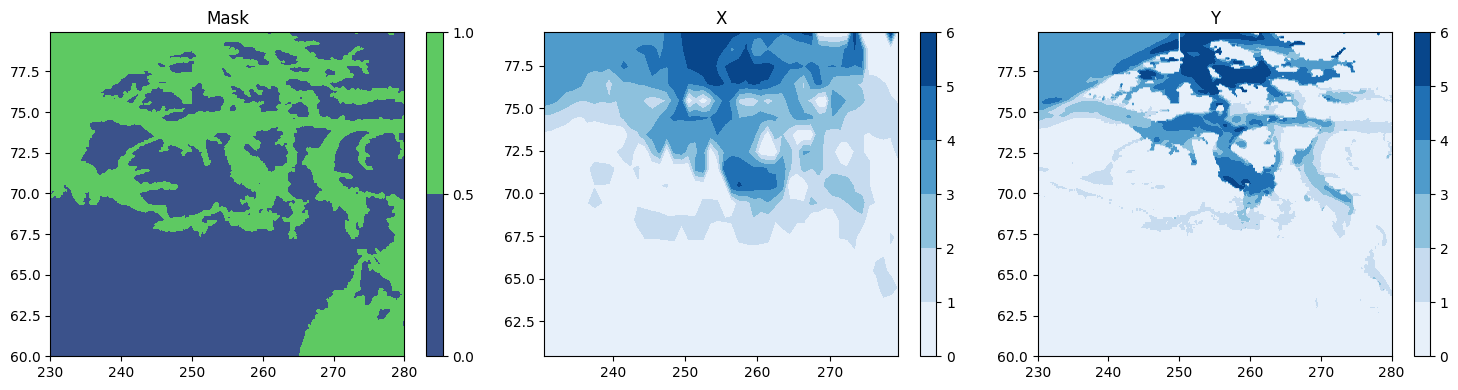

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
levels = np.linspace(0, 6, 7)

cf1 = axes[0].contourf(hlon, hlat, mask, levels=[0, 0.5, 1])
fig.colorbar(cf1, ax=axes[0])
axes[0].set_title("Mask")

cf2 = axes[1].contourf(llon, llat, X[0, 0, 0], levels=levels, cmap='Blues')
fig.colorbar(cf2, ax=axes[1])
axes[1].set_title("X")

cf3 = axes[2].contourf(hlon, hlat, Y[0, 0, 0], levels=levels, cmap='Blues')
fig.colorbar(cf3, ax=axes[2])
axes[2].set_title("Y")

plt.tight_layout()
plt.show()